# California Housing Price Prediction

This project explores the California Housing dataset and builds a linear regression model to predict median house values using demographic and geographic features.

The analysis includes data exploration, feature preprocessing, model training, and evaluation using Scikit-Learn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load the Dataset

The California Housing dataset contains demographic and geographic information from the 1990 California census. It is loaded directly from Scikit-Learn as a Pandas DataFrame.

In [2]:
from sklearn.datasets import fetch_california_housing

# as_frame=True returns the features and target as pandas objects instead of NumPy arrays.
california_housing = fetch_california_housing(as_frame=True)
# Combine the features and target into a single DataFrame.
df = california_housing.frame

## 2. Exploratory Data Analysis

We first inspect the dataset structure, check data quality, and explore relationships between key features and median house values.

In [3]:
# Preview the dataset
display(df.head())

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
# Inspect the number of observations, feature types, and non-null counts.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [5]:
# Count missing values in each column.
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

The dataset contains 20,640 observations. All features are numerical, and no missing values are present.

### Feature Overview

| Feature | Description |
|---|---|
| `MedInc` | Median income in the block group |
| `HouseAge` | Median house age in the block group |
| `AveRooms` | Average number of rooms per household |
| `AveBedrms` | Average number of bedrooms per household |
| `Population` | Population of the block group |
| `AveOccup` | Average number of household members |
| `Latitude` | Latitude of the block group's centroid |
| `Longitude` | Longitude of the block group's centroid |
| `MedHouseVal` | Median house value (prediction target) |

### Feature Correlations

A correlation matrix provides an overview of the linear relationships between the numerical features and the prediction target.

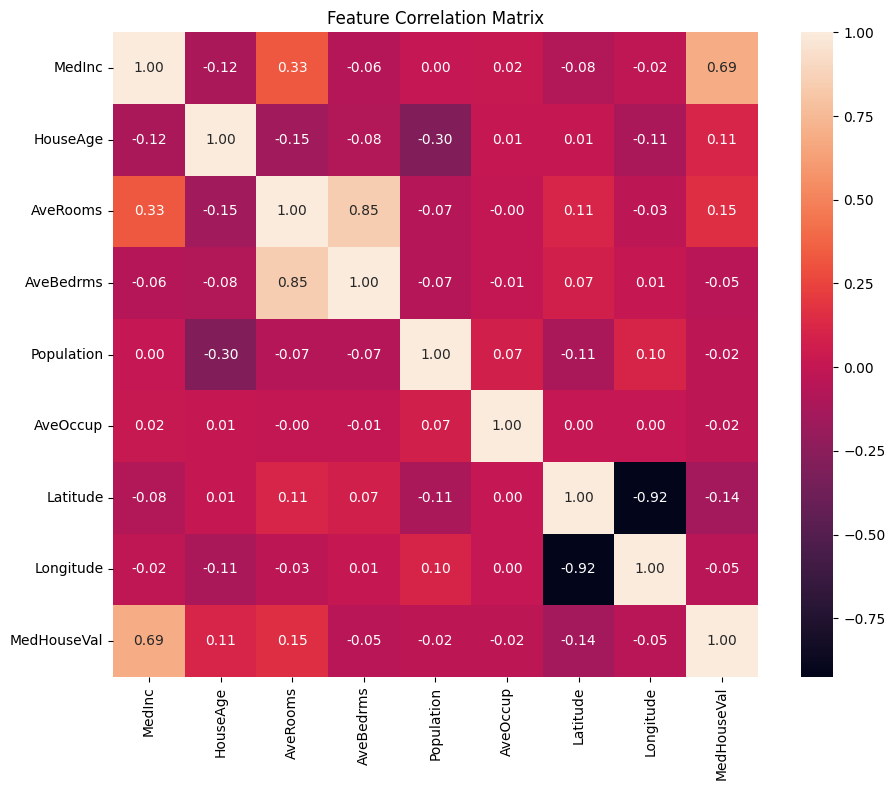

In [6]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df.corr(),
    annot=True, # Display correlation coefficients in each cell
    fmt=".2f", # Show coefficients to two decimal places
    square=True # Keep each heatmap cell square
)

plt.title("Feature Correlation Matrix")
plt.tight_layout() # Automatically adjust spacing to prevent overlapping labels
plt.show()

The correlation matrix shows that `MedInc` has the strongest linear relationship with the target, with a correlation of approximately 0.69 with `MedHouseVal`. Most other individual features show relatively weak linear correlations with house values.

Strong correlations also exist between some input features, particularly `AveRooms` and `AveBedrms` (0.85), as well as `Latitude` and `Longitude` (-0.92). These relationships suggest potential multicollinearity among some predictors.

### Median Income and House Values

Since `MedInc` shows the strongest linear correlation with the prediction target, we examine their relationship in greater detail using a hexagonal joint plot.

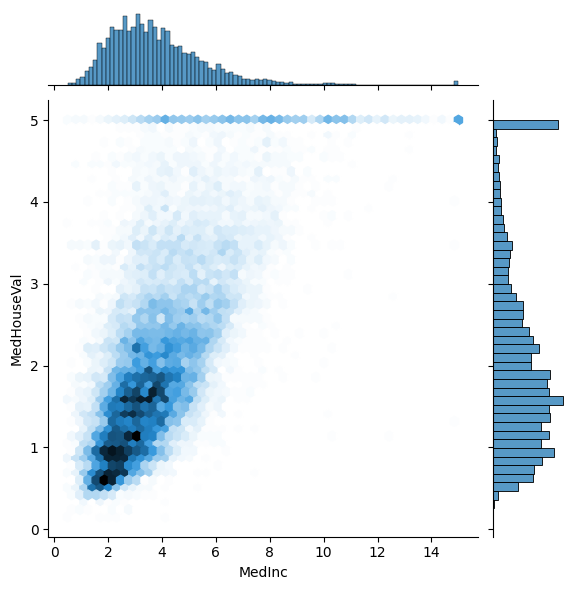

In [7]:
sns.jointplot(
    data=df,
    x="MedInc",
    y="MedHouseVal",
    kind="hex" # Use hexagonal bins to show observation density.
)

plt.show()

Median income shows a clear positive relationship with median house value: block groups with higher median income generally have higher house values.

The concentration of observations near the maximum target value also suggests that the housing-value variable is capped at its upper end.

## 3. Linear Regression Modeling

Exploratory analysis identified two important patterns:

- `MedInc` has the strongest linear relationship with the prediction target, with a correlation of approximately 0.69.
- `AveRooms` and `AveBedrms` are strongly correlated with each other, with a correlation of approximately 0.85.

To examine how these observations affect prediction, three linear regression models are compared:

1. A single-feature model using only `MedInc`.
2. A baseline model using all eight available features.
3. A reduced model that removes `AveBedrms` to reduce potential feature redundancy.

All models are evaluated on the same test observations using MAE, RMSE, and R².

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Separate all eight input features from the prediction target.
X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

# Use 20% of the observations as an unseen test set.
# random_state=42 ensures that the split is reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Single-Feature Model: Median Income

The correlation analysis showed that `MedInc` has the strongest linear relationship with `MedHouseVal`. A simple linear regression model using only `MedInc` is therefore trained first to examine how much predictive information this feature provides on its own.

In [9]:
# Use only median income as the predictor.
# Double brackets keep the selected feature as a 2D DataFrame required by scikit-learn.
X_train_medinc = X_train[["MedInc"]]
X_test_medinc = X_test[["MedInc"]]

# Train the single-feature linear regression model.
medinc_model = LinearRegression()
medinc_model.fit(X_train_medinc, y_train)

# Generate predictions.
medinc_pred = medinc_model.predict(X_test_medinc)

# Evaluate the model.
medinc_mae = mean_absolute_error(y_test, medinc_pred)
medinc_rmse = np.sqrt(mean_squared_error(y_test, medinc_pred))
medinc_r2 = r2_score(y_test, medinc_pred)

print(f"MedInc-only MAE:  {medinc_mae:.3f}")
print(f"MedInc-only RMSE: {medinc_rmse:.3f}")
print(f"MedInc-only R²:   {medinc_r2:.3f}")

MedInc-only MAE:  0.630
MedInc-only RMSE: 0.842
MedInc-only R²:   0.459


### Baseline Model

The baseline model uses all eight available features. Comparing this model with the single-feature model shows whether the remaining demographic and geographic features provide additional predictive information beyond median income alone.

In [10]:
# Train the baseline multiple linear regression model
# using all eight available features.
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# Generate predictions.
baseline_pred = baseline_model.predict(X_test)

# Evaluate the baseline model.
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2 = r2_score(y_test, baseline_pred)

print(f"Baseline MAE:  {baseline_mae:.3f}")
print(f"Baseline RMSE: {baseline_rmse:.3f}")
print(f"Baseline R²:   {baseline_r2:.3f}")

Baseline MAE:  0.533
Baseline RMSE: 0.746
Baseline R²:   0.576


### Reduced Model

The correlation matrix also showed a strong positive correlation (approximately 0.85) between `AveRooms` and `AveBedrms`.

Because both variables describe the composition of housing units and may contain overlapping information, `AveBedrms` is removed to test whether a simpler model can maintain similar predictive performance.

Although `Latitude` and `Longitude` are also strongly correlated, both are retained because together they represent the two-dimensional geographic location of each block group.

In [11]:
# Remove AveBedrms while keeping the same training and test observations.
X_train_reduced = X_train.drop(columns="AveBedrms")
X_test_reduced = X_test.drop(columns="AveBedrms")

# Train the reduced multiple linear regression model.
reduced_model = LinearRegression()
reduced_model.fit(X_train_reduced, y_train)

# Generate predictions.
reduced_pred = reduced_model.predict(X_test_reduced)

# Evaluate the reduced model.
reduced_mae = mean_absolute_error(y_test, reduced_pred)
reduced_rmse = np.sqrt(mean_squared_error(y_test, reduced_pred))
reduced_r2 = r2_score(y_test, reduced_pred)

print(f"Reduced MAE:  {reduced_mae:.3f}")
print(f"Reduced RMSE: {reduced_rmse:.3f}")
print(f"Reduced R²:   {reduced_r2:.3f}")

Reduced MAE:  0.543
Reduced RMSE: 0.740
Reduced R²:   0.582


### Model Comparison

The three models are evaluated on the same test set.

The single-feature model shows how much predictive information can be captured by `MedInc` alone. The baseline model tests whether additional features improve prediction, while the reduced model examines whether one potentially redundant feature can be removed without meaningfully reducing performance.

In [12]:
model_comparison = pd.DataFrame({
    "Model": [
        "MedInc only",
        "Baseline (8 features)",
        "Reduced (without AveBedrms)"
    ],
    "MAE": [
        medinc_mae,
        baseline_mae,
        reduced_mae
    ],
    "RMSE": [
        medinc_rmse,
        baseline_rmse,
        reduced_rmse
    ],
    "R²": [
        medinc_r2,
        baseline_r2,
        reduced_r2
    ]
})

model_comparison.round(3)

,Model,MAE,RMSE,R²
0,MedInc only,0.630,0.842,0.459
1,Baseline (8 features),0.533,0.746,0.576
2,Reduced (without AveBedrms),0.543,0.740,0.582


The single-feature model using only `MedInc` achieves an R² of 0.459, showing that median income alone captures a substantial portion of the variation in house values. This is consistent with the strong positive correlation identified during exploratory analysis.

Using all eight features improves R² from 0.459 to 0.576, while reducing both MAE and RMSE. This indicates that the remaining demographic and geographic features provide additional predictive information beyond median income alone.

After removing `AveBedrms`, the reduced model achieves performance comparable to the baseline model. MAE increases slightly from 0.533 to 0.543, while RMSE decreases from 0.746 to 0.740 and R² increases from 0.576 to 0.582. Since the reduced model uses fewer features without meaningfully reducing predictive performance, it is selected as the final model.

In [13]:
# Use the reduced model as the final model.
final_model = reduced_model
final_pred = reduced_pred

### Actual vs. Predicted Values

Based on the model comparison, the reduced model is selected as the final model because it maintains comparable predictive performance while using fewer features.

The scatter plot below compares the observed and predicted house values. Points closer to the diagonal reference line indicate more accurate predictions.

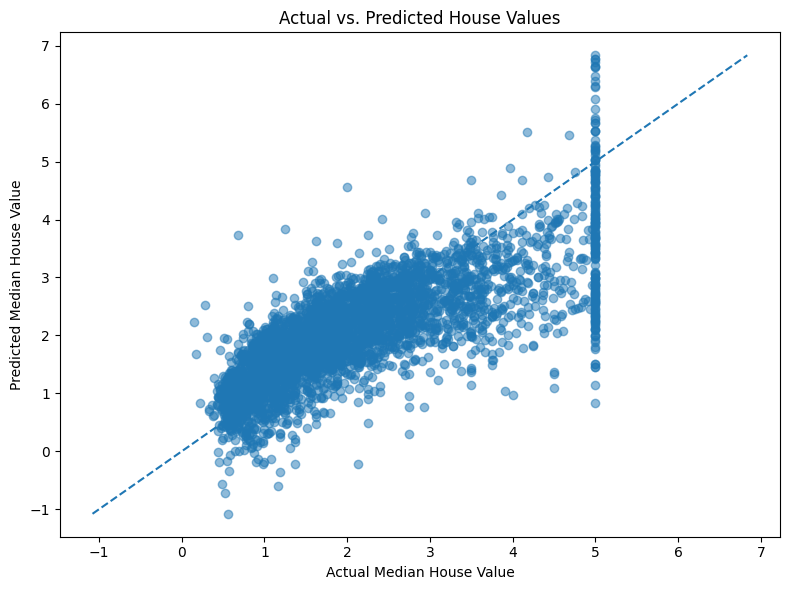

In [14]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    final_pred,
    alpha=0.5
)

# Perfect predictions would lie on the diagonal y = x.
min_value = min(y_test.min(), final_pred.min())
max_value = max(y_test.max(), final_pred.max())

plt.plot(
    [min_value, max_value], # x-coordinates of the two endpoints
    [min_value, max_value], # same values for y → y = x
    linestyle="--"
)

plt.xlabel("Actual Median House Value")
plt.ylabel("Predicted Median House Value")
plt.title("Actual vs. Predicted House Values")
plt.tight_layout()
plt.show()

The model captures the overall trend in house values, although noticeable prediction errors remain. A vertical concentration of observations appears near the maximum actual house value, which is consistent with the upper-value cap identified during exploratory analysis.

### Conclusion

Exploratory analysis showed that `MedInc` has the strongest linear relationship with median house value. A single-feature regression model confirmed that median income alone contains substantial predictive information, achieving an R² of 0.459.

However, expanding the model to include demographic and geographic features improved predictive performance, increasing R² to 0.576. This demonstrates that features with relatively weak individual correlations can still provide useful complementary information when combined in a multiple regression model.

The exploratory analysis also identified a strong correlation between `AveRooms` and `AveBedrms`. Removing `AveBedrms` produced a reduced model with comparable performance: an MAE of 0.543, an RMSE of 0.740, and an R² of 0.582. The reduced model was therefore selected as the final model because it maintains similar predictive performance with fewer features.

Overall, the linear regression model captures a meaningful portion of the variation in California house values, although substantial unexplained variation remains. This suggests that the relationships between housing characteristics and house values are not fully captured by a simple linear model.